In [1]:
pip install pandas numpy matplotlib seaborn scikit-learn


Note: you may need to restart the kernel to use updated packages.


In [5]:
import pandas as pd
df = pd.read_csv(r'C:\Users\nk10101\Downloads\archive (3).zip')
print(df.shape)

(7043, 21)


In [6]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Prvi pogled na podatke
print(df.dtypes)
print("---")
print(df.isnull().sum())

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object
---
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       

In [7]:
# Fix TotalCharges - convert from string to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print("NaN in TotalCharges:", df['TotalCharges'].isnull().sum())

# Remove rows with missing TotalCharges
df = df.dropna(subset=['TotalCharges'])
print("Customers after cleaning:", df.shape[0])

# Encode target variable Churn to 0/1
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Check churn distribution
print("\nChurn distribution:")
print(df['Churn'].value_counts())
print("\nChurn rate %:")
print(df['Churn'].value_counts(normalize=True).round(3) * 100)

NaN in TotalCharges: 11
Customers after cleaning: 7032

Churn distribution:
Churn
0    5163
1    1869
Name: count, dtype: int64

Churn rate %:
Churn
0    73.4
1    26.6
Name: proportion, dtype: float64


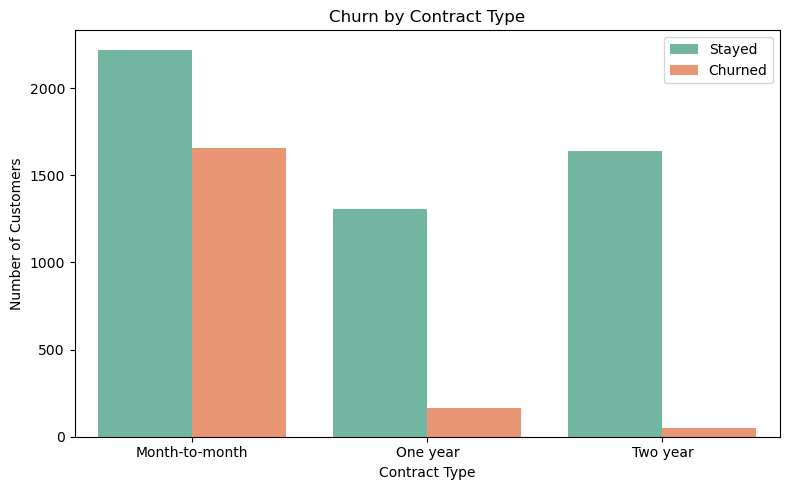

In [8]:
# Step 3 - EDA: Churn by Contract Type
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Contract', hue='Churn', palette='Set2')
plt.title('Churn by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Number of Customers')
plt.legend(labels=['Stayed', 'Churned'])
plt.tight_layout()
plt.show()

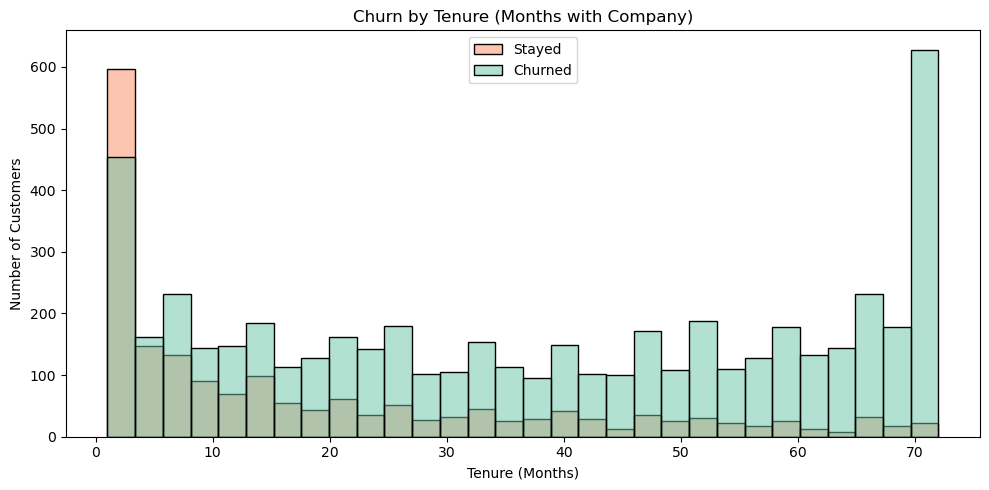

In [9]:
# Churn by Tenure
plt.figure(figsize=(10,5))
sns.histplot(data=df, x='tenure', hue='Churn', bins=30, palette='Set2')
plt.title('Churn by Tenure (Months with Company)')
plt.xlabel('Tenure (Months)')
plt.ylabel('Number of Customers')
plt.legend(labels=['Stayed', 'Churned'])
plt.tight_layout()
plt.show()

C:\Users\nk10101\AppData\Local\Temp\ipykernel_16012\748655728.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y='MonthlyCharges', palette='Set2')


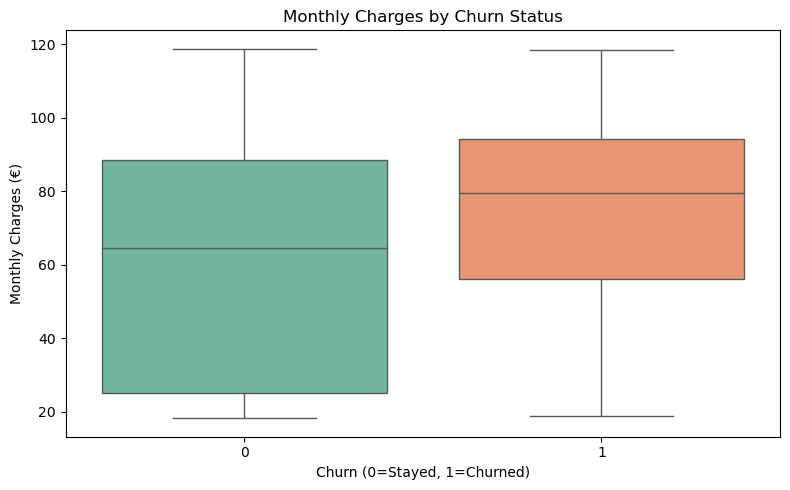

In [10]:
# Monthly Charges vs Churn
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Churn', y='MonthlyCharges', palette='Set2')
plt.title('Monthly Charges by Churn Status')
plt.xlabel('Churn (0=Stayed, 1=Churned)')
plt.ylabel('Monthly Charges (€)')
plt.tight_layout()
plt.show()

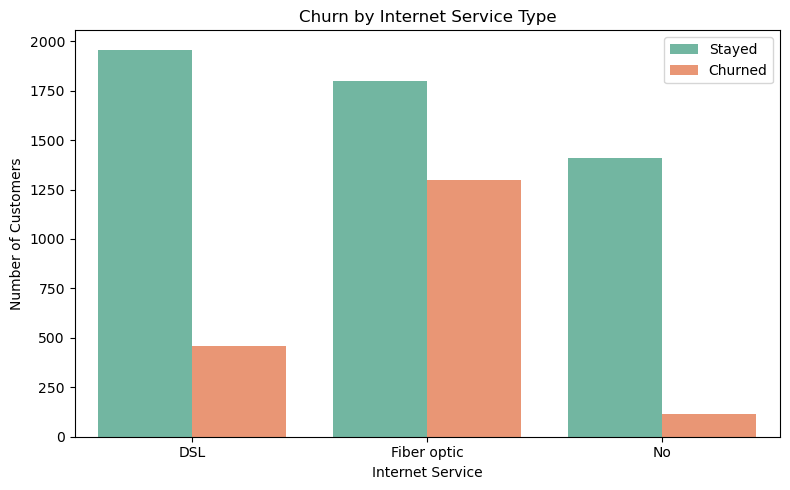

In [11]:
# Churn by Internet Service
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='InternetService', hue='Churn', palette='Set2')
plt.title('Churn by Internet Service Type')
plt.xlabel('Internet Service')
plt.ylabel('Number of Customers')
plt.legend(labels=['Stayed', 'Churned'])
plt.tight_layout()
plt.show()

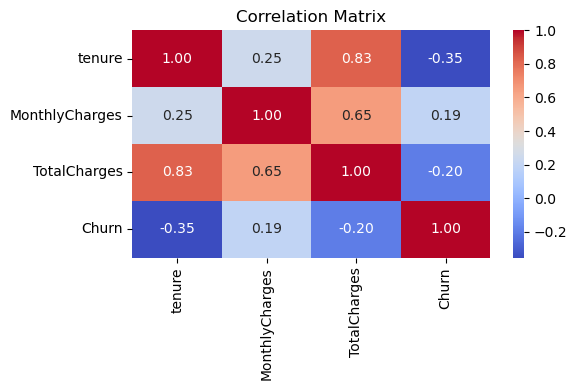

In [12]:
# Correlation heatmap - numeric variables only
plt.figure(figsize=(6,4))
numeric_df = df[['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']]
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler

# Prepare features - encode categorical variables
df_model = pd.get_dummies(df.drop(['customerID', 'Churn'], axis=1))
X = df_model
y = df['Churn']

# Split data - 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Scale numeric features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train model
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

# Evaluate
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.62      0.52      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



Adjusted threshold (0.3):
              precision    recall  f1-score   support

           0       0.90      0.75      0.82      1033
           1       0.53      0.76      0.62       374

    accuracy                           0.75      1407
   macro avg       0.71      0.76      0.72      1407
weighted avg       0.80      0.75      0.77      1407



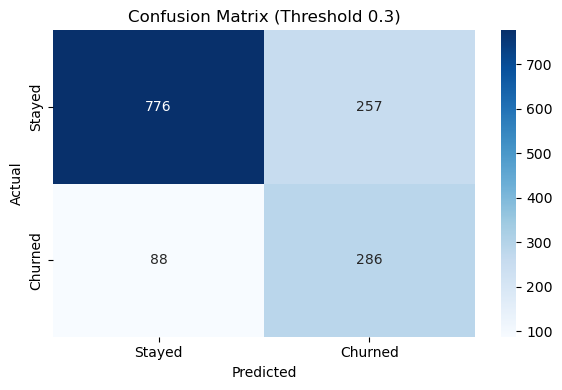

In [14]:
# Lower threshold to improve recall
y_pred_adjusted = (model.predict_proba(X_test)[:,1] >= 0.3).astype(int)
print("Adjusted threshold (0.3):")
print(classification_report(y_test, y_pred_adjusted))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_adjusted)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Stayed','Churned'],
            yticklabels=['Stayed','Churned'])
plt.title('Confusion Matrix (Threshold 0.3)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

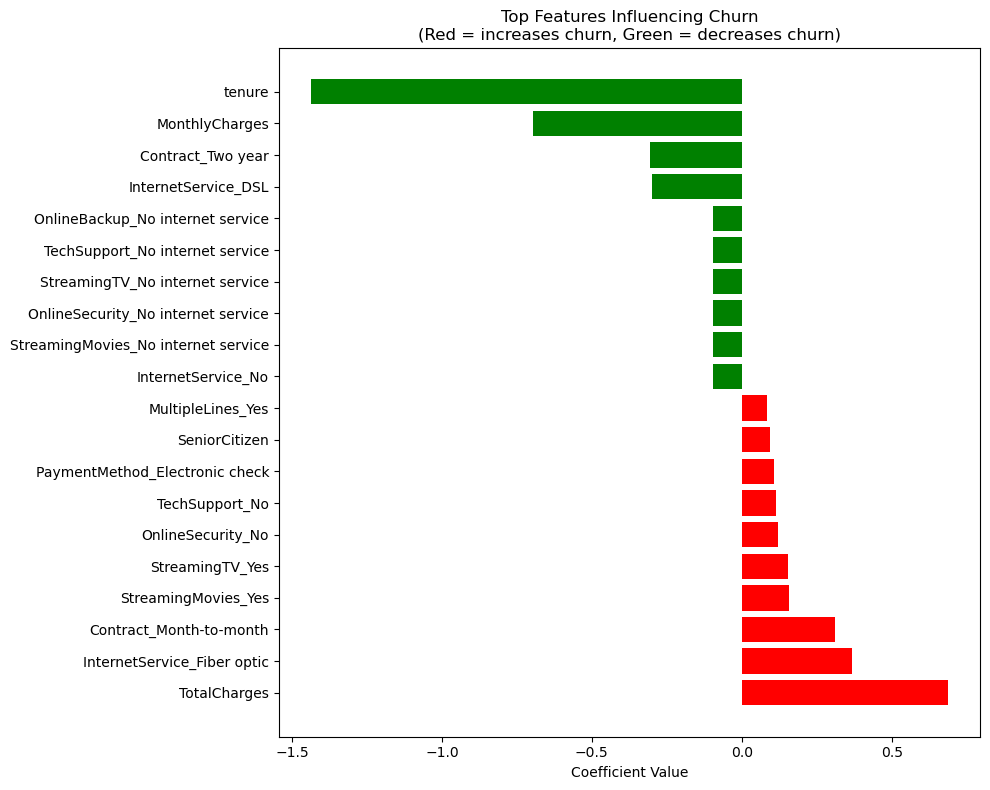

In [15]:
# Feature importance
import pandas as pd
feature_names = df_model.columns
coefficients = model.coef_[0]

feat_imp = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
}).sort_values('Coefficient', ascending=False)

# Top 10 positive and negative
top_features = pd.concat([feat_imp.head(10), feat_imp.tail(10)])

plt.figure(figsize=(10,8))
colors = ['red' if c > 0 else 'green' for c in top_features['Coefficient']]
plt.barh(top_features['Feature'], top_features['Coefficient'], color=colors)
plt.title('Top Features Influencing Churn\n(Red = increases churn, Green = decreases churn)')
plt.xlabel('Coefficient Value')
plt.tight_layout()
plt.show()